<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [3]:
cars.info()
cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


**Explanatory variable** = speed,
**Response variable** = dist,
because we can control the speed of the vehicle, whereas the breaking distance is the physical outcome of breaking from the given speed.

## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

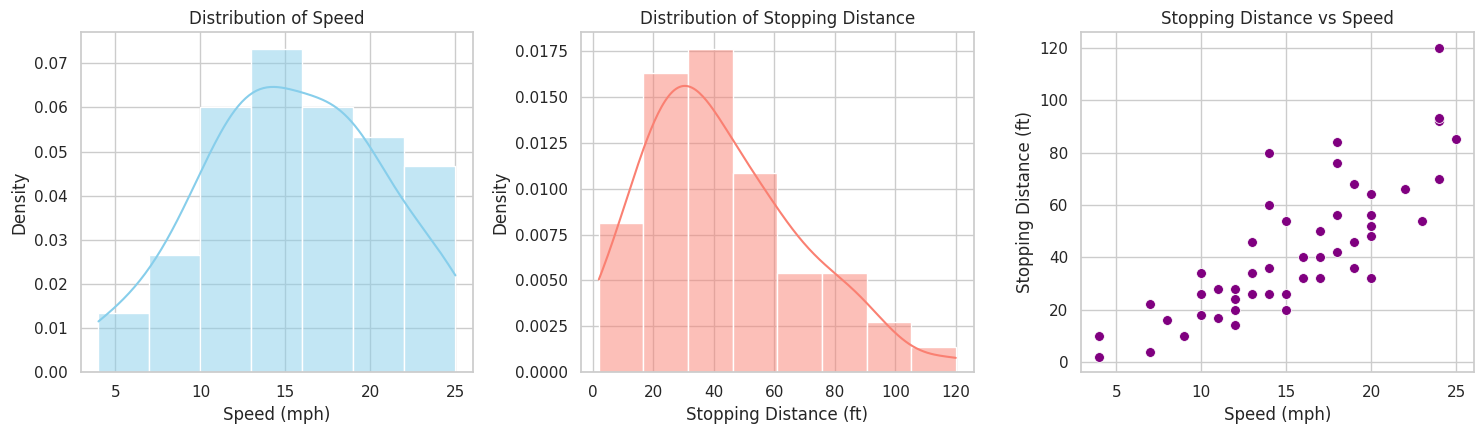

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# speed histogram
sns.histplot(cars['speed'], kde=True, ax=axes[0], color='skyblue', stat='density')
axes[0].set_title('Distribution of Speed')
axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Density')

# distance histogram
sns.histplot(cars['dist'], kde=True, ax=axes[1], color='salmon', stat='density')
axes[1].set_title('Distribution of Stopping Distance')
axes[1].set_xlabel('Stopping Distance (ft)')
axes[1].set_ylabel('Density')

# scatter plot of dist against speed
sns.scatterplot(x='speed', y='dist', data=cars, ax=axes[2], color='purple', s=50)
axes[2].set_title('Stopping Distance vs Speed')
axes[2].set_xlabel('Speed (mph)')
axes[2].set_ylabel('Stopping Distance (ft)')

plt.tight_layout()
plt.show()

**shape of the relationship**: clearly a positive correlation, linear model could provide reasonable approximation (although it looks more like a quadratic trend)

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [5]:
# your solution
x = cars["speed"]
y = cars["dist"]

n = len(cars)
sum_x = x.sum()
sum_y = y.sum()
x_bar = x.mean()
y_bar = y.mean()
sum_x2 = (x ** 2).sum()
sum_y2 = (y ** 2).sum()
sum_xy = (x * y).sum()

print(f"n          = {n}")
print(f"sum(x)     = {sum_x}")
print(f"sum(y)     = {sum_y}")
print(f"x_bar      = {x_bar:.4f}")
print(f"y_bar      = {y_bar:.4f}")
print(f"sum(x^2)   = {sum_x2}")
print(f"sum(y^2)   = {sum_y2}")
print(f"sum(x * y) = {sum_xy}")

# Model WITH intercept
beta_1_hat = (sum_xy - n * x_bar * y_bar) / (sum_x2 - (n * (x_bar**2)))
beta_0_hat = y_bar - beta_1_hat * x_bar

# Model WITHOUT intercept
beta_1_hat_no_int = sum_xy / sum_x2

print("\n--- Parameter Estimates ---")
print(f"With Intercept:    beta_0_hat = {beta_0_hat:.4f}, beta_1_hat = {beta_1_hat:.4f}")
print(f"Without Intercept: beta_1_hat = {beta_1_hat_no_int:.4f}")

n          = 50
sum(x)     = 770
sum(y)     = 2149
x_bar      = 15.4000
y_bar      = 42.9800
sum(x^2)   = 13228
sum(y^2)   = 124903
sum(x * y) = 38482

--- Parameter Estimates ---
With Intercept:    beta_0_hat = -17.5791, beta_1_hat = 3.9324
Without Intercept: beta_1_hat = 2.9091


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [6]:
# Model WITH intercept
y_pred_with = beta_0_hat + beta_1_hat * x
residuals_with = y - y_pred_with
sse_with = np.sum(residuals_with**2)
df_with = n - 2
s2_with = sse_with / df_with

# Model WITHOUT intercept
y_pred_no = beta_1_hat_no_int * x
residuals_no = y - y_pred_no
sse_no = np.sum(residuals_no**2)
df_no = n - 1
s2_no = sse_no / df_no

print(f"Model WITH Intercept:    SSE = {sse_with:.4f}, df = {df_with}, s_n^2 = {s2_with:.4f}")
print(f"Model WITHOUT Intercept: SSE = {sse_no:.4f}, df = {df_no}, s_n^2 = {s2_no:.4f}")

Model WITH Intercept:    SSE = 11353.5211, df = 48, s_n^2 = 236.5317
Model WITHOUT Intercept: SSE = 12953.7768, df = 49, s_n^2 = 264.3628


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [7]:
S_xx = np.sum((x - x_bar) ** 2)

# Model WITH intercept
var_beta_1_hat = s2_with / S_xx
se_beta_1_hat = np.sqrt(var_beta_1_hat)

var_beta_0_hat = s2_with * ((1 / n) + (x_bar**2 / S_xx))
se_beta_0_hat = np.sqrt(var_beta_0_hat)

# Model WITHOUT intercept
var_beta_1_hat_no_int = s2_no / sum_x2
se_beta_1_hat_no_int = np.sqrt(var_beta_1_hat_no_int)

# Statsmodel
model_with_sm = sm.OLS(y, sm.add_constant(x)).fit()
model_no_sm = sm.OLS(y, x).fit()

print("--- Model WITH Intercept ---")
print(f"Manual SE(beta_0_hat): {se_beta_0_hat:.6f} | statsmodels: {model_with_sm.bse['const']:.6f}")
print(f"Manual SE(beta_1_hat): {se_beta_1_hat:.6f} | statsmodels: {model_with_sm.bse['speed']:.6f}")

print("\n--- Model WITHOUT Intercept ---")
print(f"Manual SE(beta_1_hat_no_int): {se_beta_1_hat_no_int:.6f} | statsmodels: {model_no_sm.bse['speed']:.6f}")

--- Model WITH Intercept ---
Manual SE(beta_0_hat): 6.758440 | statsmodels: 6.758440
Manual SE(beta_1_hat): 0.415513 | statsmodels: 0.415513

--- Model WITHOUT Intercept ---
Manual SE(beta_1_hat_no_int): 0.141369 | statsmodels: 0.141369


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

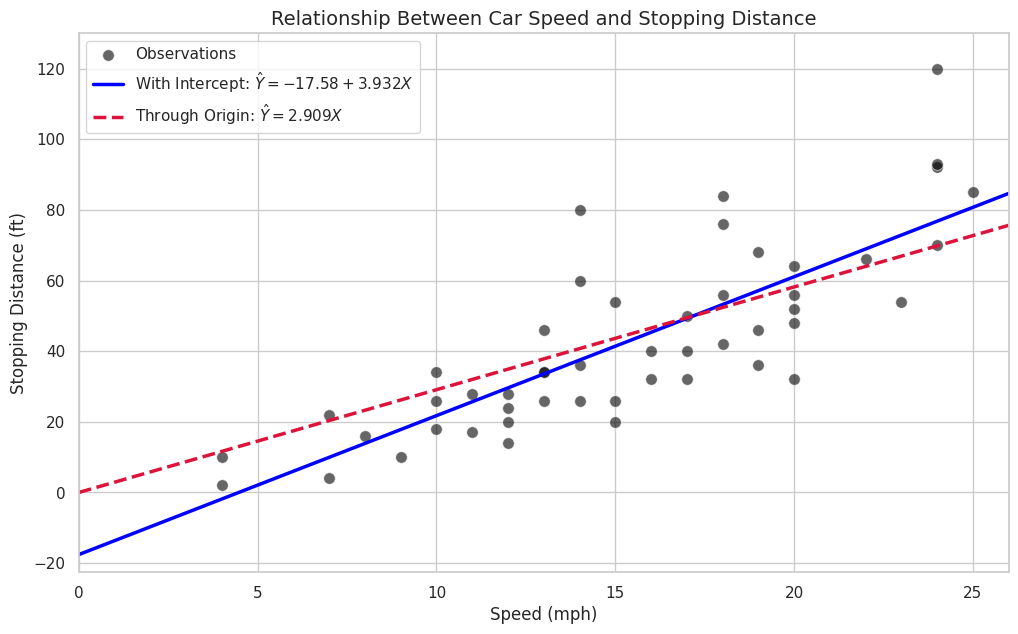

In [8]:
x_range = np.linspace(0, cars["speed"].max() + 1, 100)
y_range_with = beta_0_hat + beta_1_hat * x_range
y_range_no = beta_1_hat_no_int * x_range

plt.figure(figsize=(12, 7))
sns.scatterplot(x=cars["speed"], y=cars["dist"], color='black', alpha=0.6, s=70, label='Observations')

# Model WITH intercept
plt.plot(x_range, y_range_with,
         color='blue', linestyle='-', linewidth=2.5,
         label=f'With Intercept: $\\hat{{Y}} = {beta_0_hat:.2f} + {beta_1_hat:.3f}X$')

# Model WITHOUT intercept
plt.plot(x_range, y_range_no,
         color='crimson', linestyle='--', linewidth=2.5,
         label=f'Through Origin: $\\hat{{Y}} = {beta_1_hat_no_int:.3f}X$')

plt.xlim(0, cars["speed"].max() + 1)
plt.ylim(min(0, beta_0_hat) - 5, cars["dist"].max() + 10)

plt.xlabel('Speed (mph)', fontsize=12)
plt.ylabel('Stopping Distance (ft)', fontsize=12)
plt.title('Relationship Between Car Speed and Stopping Distance', fontsize=14)

plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

The slopes differ because the model without intercept has an additional constraint (it has to go through the origin). Therefore it has to have a lower slope (to balance the residuals across the observed data).

The model WITHOUT intercept makes more physical sense for the lower speeds, because for any speed > 0 it has a positive stopping distance. However, for the speeds greater than 5 mph, the model WITH intercept makes more sense since it clearly represents the data better.


## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [10]:
speeds = [20, 30]

for s in speeds:
    pred_with = beta_0_hat + beta_1_hat * s
    pred_no = beta_1_hat_no_int * s
    print(f"At {s} mph:")
    print(f"  Model WITH Intercept:    {pred_with:.2f} ft")
    print(f"  Model WITHOUT Intercept: {pred_no:.2f} ft\n")

At 20 mph, both results seem to be plausible compared to the data.

At 30 mph, I would say that the model WITH intercept (100 ft) is a more plausible result, since in real life stopping distance probably has a quadratic dependency rather than a linear one.

Since we have the data from 4 to 25 mph, the prediction for 30 mph is an extrapolation.

## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

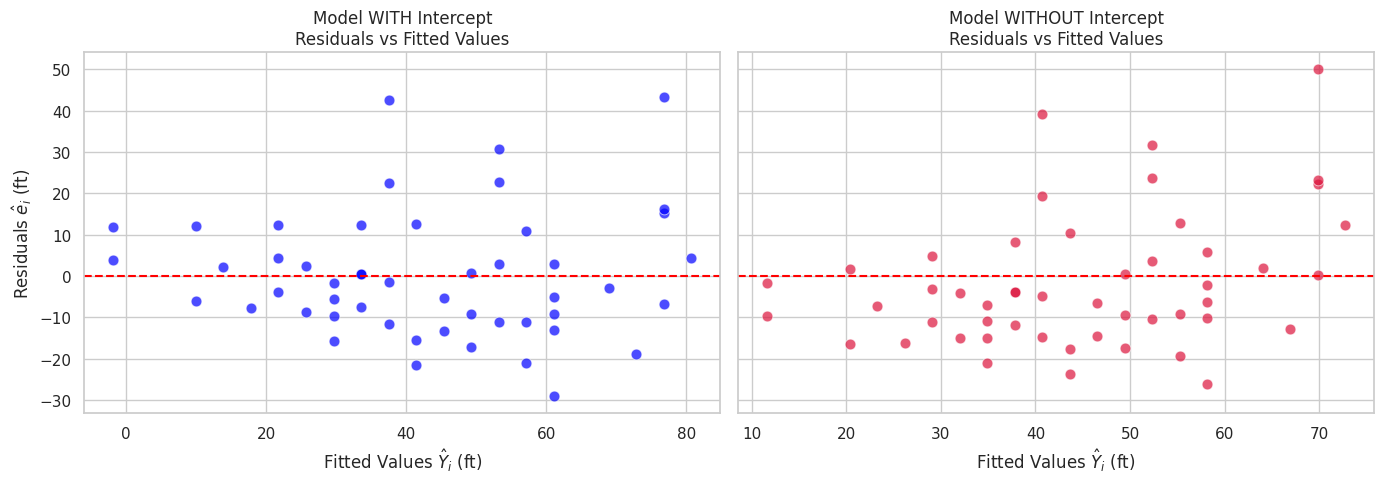

Mean of residuals (WITH intercept):    0.000000
Mean of residuals (WITHOUT intercept): -1.820635


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Model WITH intercept
sns.scatterplot(x=y_pred_with, y=residuals_with, ax=axes[0], color='blue', alpha=0.7, s=60)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Model WITH Intercept\nResiduals vs Fitted Values')
axes[0].set_xlabel('Fitted Values $\\hat{Y}_i$ (ft)')
axes[0].set_ylabel('Residuals $\\hat{e}_i$ (ft)')

# Model WITHOUT intercept
sns.scatterplot(x=y_pred_no, y=residuals_no, ax=axes[1], color='crimson', alpha=0.7, s=60)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Model WITHOUT Intercept\nResiduals vs Fitted Values')
axes[1].set_xlabel('Fitted Values $\\hat{Y}_i$ (ft)')

plt.tight_layout()
plt.show()

print(f"Mean of residuals (WITH intercept):    {residuals_with.mean():.6f}")
print(f"Mean of residuals (WITHOUT intercept): {residuals_no.mean():.6f}")

I would say that models perform quite similarly, although the one with intercept looks a little better.

1. it seems like the residuals are quite clustered in [-10, +10] range for lower speeds, but expand to [-40, +40] for higher speeds => the constant error variance assumption is probably violated.

2. Also, a lot of the residuals in the middle range seem to be negative, while the residuals at the edges seem to be positive => this could imply that the underlying relationship is quadratic.

## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [15]:
x_outlier = np.append(x, 5)
y_outlier = np.append(y, 120)

n_out = len(x_outlier)
x_bar_out = x_outlier.mean()
y_bar_out = y_outlier.mean()

sum_x2_out = np.sum(x_outlier**2)
sum_xy_out = np.sum(x_outlier * y_outlier)
S_xx_out = np.sum((x_outlier - x_bar_out)**2)
S_xy_out = np.sum((x_outlier - x_bar_out) * (y_outlier - y_bar_out))

# Model WITH intercept
beta_1_hat_out = S_xy_out / S_xx_out
beta_0_hat_out = y_bar_out - beta_1_hat_out * x_bar_out

# Model WITHOUT intercept
beta_1_hat_no_int_out = sum_xy_out / sum_x2_out

print("--- MODEL WITH INTERCEPT ---")
print(f"Original:     beta_0 = {beta_0_hat:6.2f},  beta_1 = {beta_1_hat:.4f}")
print(f"With Outlier: beta_0 = {beta_0_hat_out:6.2f},  beta_1 = {beta_1_hat_out:.4f}")

print("\n--- MODEL WITHOUT INTERCEPT ---")
print(f"Original:     beta_1 = {beta_1_hat_no_int:.4f}")
print(f"With Outlier: beta_1 = {beta_1_hat_no_int_out:.4f}")

--- MODEL WITH INTERCEPT ---
Original:     beta_0 = -17.58,  beta_1 = 3.9324
With Outlier: beta_0 =  -2.89,  beta_1 = 3.1179

--- MODEL WITHOUT INTERCEPT ---
Original:     beta_1 = 2.9091
With Outlier: beta_1 = 2.9489


The more sensitive model is definitely the one WITH intercept.

## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

Suggested next steps:

1. Including speed ** 2 as an additional regressor to explicitly account for kinetic energy, E_k = 0.5 mv**2 = F_{friction} * d_{brake}

2. Transform the response variable to \sqrt{dist} and regress it against speed. Because dist is basically quadratic in speed squared, taking the square root linearizes the relationship while also reducing high-speed variance.

In [18]:
df = pd.DataFrame({'speed': x, 'dist': y})
df['speed2'] = df['speed'] ** 2

# Linear model
X_lin = sm.add_constant(df['speed'])
model_lin = sm.OLS(df['dist'], X_lin).fit()

# Quadratic model
X_quad = sm.add_constant(df[['speed', 'speed2']])
model_quad = sm.OLS(df['dist'], X_quad).fit()

print(model_quad.summary().tables[1])
print(f"\nLinear SSE:    {sse_with:.2f}  |  R2: {model_lin.rsquared:.4f}")
print(f"Quadratic SSE: {model_quad.ssr:.2f}  |  R2: {model_quad.rsquared:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4701     14.817      0.167      0.868     -27.338      32.278
speed          0.9133      2.034      0.449      0.656      -3.179       5.006
speed2         0.1000      0.066      1.515      0.136      -0.033       0.233

Linear SSE:    11353.52  |  R2: 0.6511
Quadratic SSE: 10824.72  |  R2: 0.6673


While adding $\text{speed}^2$ only increases $R^2$ modestly from $0.651$ to $0.667$, the quadratic specification is a substantial theoretical and diagnostic improvement. The squared term is statistically significant, eliminates the non-linear U-shape in the residuals, aligns with kinetic energy physics ($d \propto v^2$), and prevents severe underestimation of stopping distances at higher speeds.